# Задание 4 — Логистика и поставки

In [1]:
import os, io, warnings
import boto3
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid')

PG_URI = (
    f"postgresql+psycopg2://"
    f"{os.getenv('PG_USER','oilfield')}:{os.getenv('PG_PASSWORD','oilfield123')}"
    f"@{os.getenv('PG_HOST','postgres')}:{os.getenv('PG_PORT','5432')}"
    f"/{os.getenv('PG_DB','oilfield')}"
)
MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT',   'http://minio:9000')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY', 'minioadmin')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY', 'minioadmin123')
BUCKET           = os.getenv('MINIO_BUCKET',     'oilfield')

engine = create_engine(PG_URI)

s3 = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
)

def read_parquet(bucket, prefix):
    resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    frames = []
    for obj in resp.get('Contents', []):
        if obj['Key'].endswith('.parquet'):
            buf = io.BytesIO()
            s3.download_fileobj(bucket, obj['Key'], buf)
            buf.seek(0)
            frames.append(pq.read_table(buf).to_pandas())
    return pd.concat(frames, ignore_index=True)

## 1. Загрузка данных

In [2]:
deliveries_df = read_parquet(BUCKET, 'deliveries/deliveries.parquet')
drivers_df    = read_parquet(BUCKET, 'drivers/drivers.parquet')

deliveries_df['date'] = pd.to_datetime(deliveries_df['date'])
deliveries_df['cost_per_km'] = deliveries_df['cost_usd'] / deliveries_df['distance_km']

print(f'deliveries: {deliveries_df.shape}')
print(f'drivers:    {drivers_df.shape}')
display(deliveries_df.head())

deliveries: (30, 13)
drivers:    (5, 4)


,delivery_id,date,source,destination,product_type,volume_ton,cost_usd,delay_hours,distance_km,weather_conditions,driver_id,vehicle_id,cost_per_km
0,1,2025-10-01,Base-Khanty,Station-01,Diesel,32.5,2100.50,0.0,180.0,Clear,1,1,11.669444
1,2,2025-10-01,Base-Tomsk,Station-02,Gasoline,28.0,1850.00,1.5,150.0,Rain,2,2,12.333333
2,3,2025-10-01,Base-Tyumen,Station-03,Diesel,22.0,1650.25,0.0,120.0,Clear,3,3,13.752083
3,4,2025-10-02,Base-Khanty,Station-04,Kerosene,35.0,2400.80,2.0,210.0,Fog,4,1,11.432381
4,5,2025-10-02,Base-Tomsk,Station-05,Gasoline,20.5,1500.00,0.5,110.0,Cloudy,5,2,13.636364


## 2. Задержки по погоде

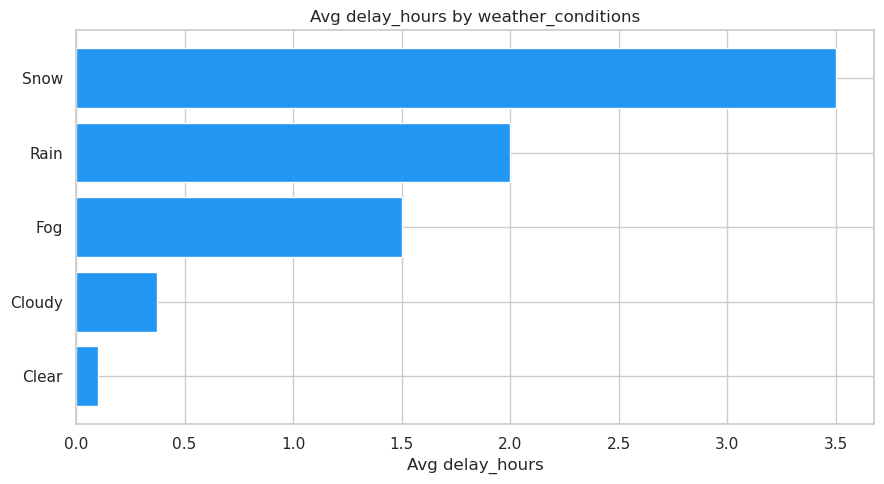

,weather_conditions,avg_delay_hours,count
0,Clear,0.100,15
1,Cloudy,0.375,4
2,Fog,1.500,3
3,Rain,2.000,5
4,Snow,3.500,3


In [3]:
weather_delay = (
    deliveries_df.groupby('weather_conditions')
    .agg(avg_delay_hours=('delay_hours', 'mean'), count=('delivery_id', 'count'))
    .reset_index()
    .sort_values('avg_delay_hours', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(weather_delay['weather_conditions'], weather_delay['avg_delay_hours'], color='#2196F3')
ax.set_xlabel('Avg delay_hours')
ax.set_title('Avg delay_hours by weather_conditions')
plt.tight_layout()
plt.show()
display(weather_delay)

## 3. График 1 — Cost vs Distance

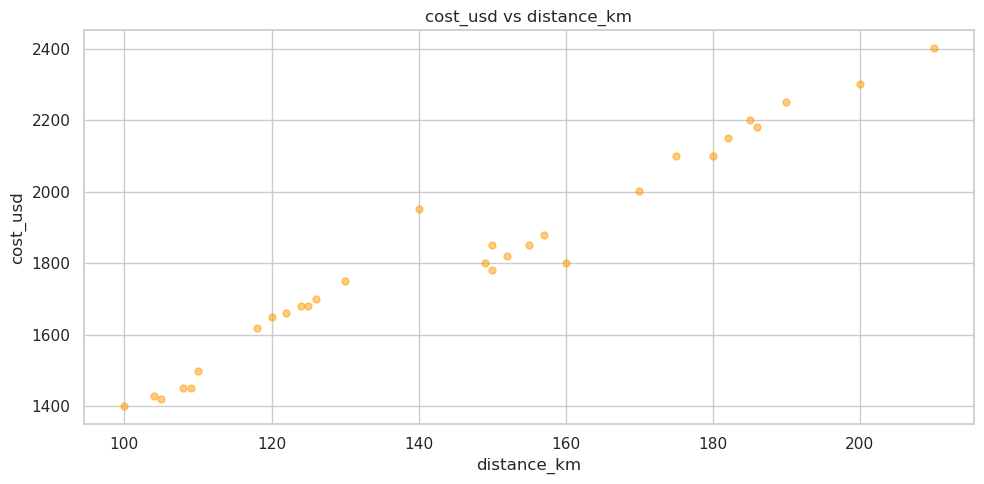

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(deliveries_df['distance_km'], deliveries_df['cost_usd'], alpha=0.5, s=25, color='#FF9800')
ax.set_xlabel('distance_km')
ax.set_ylabel('cost_usd')
ax.set_title('cost_usd vs distance_km')
plt.tight_layout()
plt.show()

## 4. KPI по водителям

In [5]:
df_driver = deliveries_df.merge(drivers_df[['driver_id', 'name', 'experience_years', 'region']], on='driver_id')

driver_kpi = (
    df_driver.groupby('name')
    .agg(
        total_deliveries=('delivery_id', 'count'),
        avg_delay_hours=('delay_hours',  'mean'),
        total_volume=('volume_ton',      'sum'),
        avg_cost_per_km=('cost_per_km',  'mean'),
        total_distance=('distance_km',   'sum'),
    )
    .reset_index()
    .sort_values('avg_delay_hours')
    .round(2)
)
display(driver_kpi)

,name,total_deliveries,avg_delay_hours,total_volume,avg_cost_per_km,total_distance
2,Ivan Petrov,5,0.20,168.4,11.73,941.0
0,Aleksey Smirnov,7,0.43,165.1,13.26,895.0
3,Pavel Egorov,4,0.62,130.7,11.75,737.0
4,Sergey Sidorov,7,0.79,195.2,12.30,1053.0
1,Andrey Kuznetsov,7,2.29,141.1,13.59,766.0


## 5. Сохранение в PostgreSQL

In [6]:
driver_kpi.to_sql('analytics_logistics', engine, if_exists='replace', index=False)
print(f'Saved {len(driver_kpi)} rows to analytics_logistics')

Saved 5 rows to analytics_logistics
